# Explore here

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv', sep=';')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Tenemos escalas distintas pero no tampoco tanto, van en rangos bastantes cercanos, entre 0 y 100, otras entre 0 y 1. La escalas no están tan alejadas/diferentes, asique vamos a usar una estandarización. 

A nosotros nos pidieron predecir: MALO, MEDIO Y BUENO, y en la columna 'quality' (que está en numérico) hay valores más alto de 3.

Vamos a ver qué hay en 'quality':

In [2]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

y aquí nos muestra los números que hay en la columna que van del 3 al 8, cómo podemos dividir esos número en malo, medio y bueno? Tenemos que mapear esta columna:

In [3]:
df['quality'] = df['quality'].map({3:'bad', 4:'bad', 5:'mid', 6: 'mid', 7:'good', 8:'good'})

Lo que hacemos con 'map' es aplicar una transformación a una columna. Tmb lo podemos hacer con una función y un for (opción más larga pero tmb correcta).


In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,mid
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,mid
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,mid
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,mid
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,mid


In [5]:
# Bueno, hasta acá ya tenemos nuestro 'quality' categorizado, y tenemos que estandarizar nuestras variables objetivo, asique lo primero que tenemos que hacer es definir nuestras X e Y.

x= df.drop(columns=['quality'])
y= df['quality']

# Vamos a hacer nuestra división en entrenamiento y test:

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

x_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,8.7,0.690,0.31,3.0,0.086,23.0,81.0,1.00020,3.48,0.74,11.6
354,6.1,0.210,0.40,1.4,0.066,40.5,165.0,0.99120,3.25,0.59,11.9
342,10.9,0.390,0.47,1.8,0.118,6.0,14.0,0.99820,3.30,0.75,9.8
834,8.8,0.685,0.26,1.6,0.088,16.0,23.0,0.99694,3.32,0.47,9.4
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9


In [6]:
# Ahora estandarizamos:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_esc = scaler.fit_transform(x_train, y_train)

x_test_esc = scaler.transform(x_test) 

# Y luego los tengo que volver DataFrame:

x_train_esc = pd.DataFrame(x_train_esc, columns= x_train.columns, index= x_train.index)
x_test_esc = pd.DataFrame(x_test_esc, columns= x_test.columns, index= x_test.index)

x_train_esc.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
493,0.218332,0.889712,0.192092,0.309726,-0.049642,0.691007,1.042934,1.846696,1.093500,0.458223,1.123177
354,-1.290166,-1.788783,0.652753,-0.805080,-0.455214,2.388473,3.593870,-3.004491,-0.400439,-0.401197,1.408272
342,1.494753,-0.784347,1.011045,-0.526378,0.599272,-0.957960,-0.991742,0.768655,-0.075669,0.515517,-0.587390
834,0.276351,0.861811,-0.063831,-0.665729,-0.009085,0.012020,-0.718427,0.089488,0.054238,-1.088733,-0.967516
705,0.044274,2.814880,-0.626861,2.399985,-0.313264,-0.472970,0.222990,1.199871,0.379008,-0.974144,-0.492358


In [7]:
# como ya tenemos escalados nuestros x de entrenamiento y test, ahora podemos hacer predicciones:

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(x_train_esc, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['bad','good','mid']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [8]:
# Tenemos nuestro modelo, ahora podemos hacer predicciones:

y_pred = model.predict(x_test_esc)

y_pred

array(['mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       'mid', 'good', 'mid', 'mid', 'mid', 'mid', 'good', 'mid', 'mid',
       'good', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       'mid', 'good', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'good',
       'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       'mid', 'good', 'mid', 'mid', 'mid', 'good', 'mid', 'mid', 'mid',
       'mid', 'mid', 'mid', 'mid', 'good', 'mid', 'mid', 'good', 'mid',
       'good', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'good', 'mid',
       'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       'mid', 'mid', 'mid', 'mid', 'good', 'mid', 'mid', 'mid', 'mid',
       'mid', 'mid', 'good', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid', 'mid',
       

In [9]:
# vamos a ver cómo andubieronnuestras predicciones: 

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.846875

Vemos que tenemos un 84% de precisión. 

Las consignas del proyecto nos piden tmb realizar una Matríz de confusión y un Reporte de Clasificación:

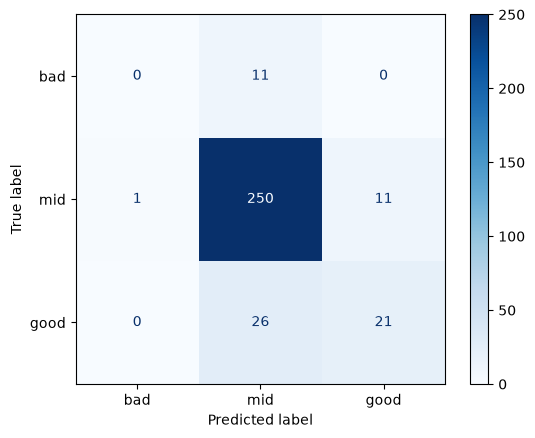

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

labels=['bad', 'mid', 'good']
matriz_confusion = confusion_matrix(y_test, y_pred, labels= labels)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels= labels)

disp.plot(cmap= plt.cm.Blues)
plt.show()

Podemos ver de esta matríz de confusión que los datos están desvalanseados, por eso el 80% de precisión. La Mayoría de los vinos son medios. 

In [11]:
# Y ahora el Reporte de Clasificación:

report = classification_report(y_test, y_pred, labels=labels)
print(report)

              precision    recall  f1-score   support

         bad       0.00      0.00      0.00        11
         mid       0.87      0.95      0.91       262
        good       0.66      0.45      0.53        47

    accuracy                           0.85       320
   macro avg       0.51      0.47      0.48       320
weighted avg       0.81      0.85      0.82       320



Este reporte nos muestra la precisión por clase (bad, mid y good), el accuracy visto de distintas formas. El Recall (81%) y el F1 score. El suport es sobre cuánto lo está haciendo. 

Lo malo es que los vinos malos no los detecta.

In [16]:
# Optimización de K: (acá hacemos 20 modelos de vecinos mas cercanos con distintos K)

k = []
accuracies =[]

for i in range(1,21):
    modelk = KNeighborsClassifier(n_neighbors=i)
    modelk.fit(x_train_esc, y_train)
    y_pred = modelk.predict(x_test_esc)
    accuracies.append(accuracy_score(y_test, y_pred))
    k.append(i)


Acá hicimos 20 modelos de vecinos mas cercanos con distintos K, ahora queda graficarlos:

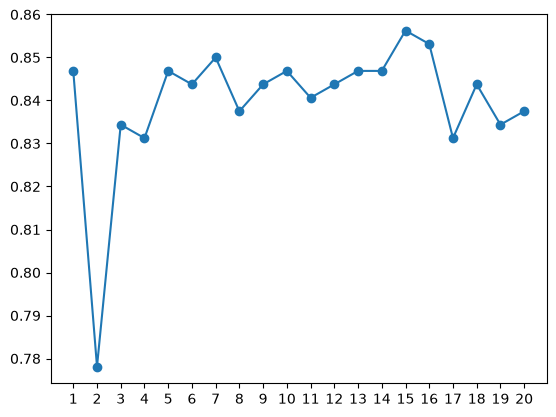

In [17]:
plt.plot(k,accuracies,marker='o')
plt.xticks(k)
plt.show()

Acá podemos visualizar el número de K y los distintos accuracy que obtuvimos. El mejor es el 15 y el peor es 2. Así se consigue el mejor K.

In [27]:
import numpy as np

def predict_wine_quality(lista):
    datos = np.array(lista)
    datos= datos.reshape(1, -1)
    datos_esc = scaler.transform(datos)
    prediccion = model.predict(datos_esc)[0]
    traducciones = {
        'bad' : 'Este vino es de baja calidad',
        'mid' : 'Este vino es de calidad media',
        'good': 'Este vino es de excelente calidad'
    }

    return traducciones.get(prediccion)



In [28]:
predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'Este vino es de calidad media'

Generalmente es así como se construye una función con el escalador y el modelo.